# Preparación y modelado — Clasificación de viviendas, Censo 2024

Proyecto: **Radiografía de la Vulnerabilidad Habitacional en Bolivia**. Este notebook reproduce la población y el objetivo desde los archivos oficiales, prepara predictores sin fuga de información y compara regresión logística con árbol de decisión. El IPS y la clase `vivienda_precaria` son definiciones de este proyecto, no indicadores oficiales del INE. Clase positiva: **1 = vivienda precaria**.

## 1. Datos, documentación y población analítica

Leemos solamente las columnas necesarias para filtrar, construir el objetivo y modelar. El inventario se obtiene de la cabecera completa. Las categorías se leen como texto para conservar los códigos sin convertirlos en magnitudes. Los criterios se reproducen exactamente del notebook de entendimiento: vivienda particular (`v01_tipoviv` 1–6), ocupada con personas presentes (`v02_condocup` 0–1), `tot_pers > 0` y preguntas base de servicios aplicables. Las etiquetas del diccionario se usan para documentar predictores.

In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

DATA = Path("data")
CSV = DATA / "Vivienda_CPV-2024.csv"
DICT = DATA / "Diccionario de variables CPV 2024.xlsx"
PDF = DATA / "Cuestionario censal 2024.pdf"
assert all(p.is_file() for p in (CSV, DICT, PDF))
columnas_csv = pd.read_csv(CSV, sep=";", encoding="utf-8-sig", nrows=0).columns.tolist()
print("Variables originales del CSV:", len(columnas_csv))
print("Nombres:", columnas_csv)

predictoras = ["urbrur", "v01_tipoviv", "v03_pared", "v05_techo", "v06_piso",
               "v11_basura", "v13_habitac", "v14_dormit", "v17_tenencia", "tip_hog"]
fuentes_objetivo = ["v07_aguapro", "v15_servsan", "v16_desague", "v09_energia", "v19e_f"]
columnas_lectura = list(dict.fromkeys(["v01_tipoviv", "v02_condocup", "tot_pers"] + fuentes_objetivo + predictoras))
assert set(columnas_lectura).issubset(columnas_csv)
df_base = pd.read_csv(CSV, sep=";", encoding="utf-8-sig", usecols=columnas_lectura,
                      dtype={c:"category" for c in columnas_lectura})
assert len(df_base) == 4_490_488, "La base difiere del notebook de entendimiento; detener el modelado."
print("Registros originales:", len(df_base), "| Columnas cargadas:", len(df_base.columns))
print("Memoria de columnas necesarias:", round(df_base.memory_usage(deep=True).sum()/1024**2, 1), "MiB")

particular = df_base["v01_tipoviv"].astype("string").isin({"1","2","3","4","5","6"})
presente = df_base["v02_condocup"].astype("string").isin({"0","1"})
personas = pd.to_numeric(df_base["tot_pers"].astype("string"), errors="coerce").gt(0)
aplica = df_base[["v07_aguapro","v15_servsan","v09_energia","v19e_f"]].notna().all(axis=1)
df_analisis = df_base.loc[particular & presente & personas & aplica].copy()
assert len(df_analisis) == 3_623_711, "Población analítica distinta: detener el modelado."
print("Viviendas analíticas:", len(df_analisis))
del df_base, particular, presente, personas, aplica
_ = gc.collect()

Variables originales del CSV: 48
Nombres: ['idep', 'iprov', 'imun', 'i00', 'urbrur', 'v01_tipoviv', 'v02_condocup', 'v03_pared', 'v04_revoq', 'v05_techo', 'v06_piso', 'v07_aguapro', 'v08_aguadist', 'v09_energia', 'v10_combus', 'v11_basura', 'v12_cocina', 'v13_habitac', 'v14_dormit', 'v15_servsan', 'v16_desague', 'v17_tenencia', 'v18a_bici', 'v18b_moto', 'v18c_auto', 'v18d_carreta', 'v18e_bote', 'v18f_refri', 'v18g_micro', 'v18h_calefon', 'v18i_aire', 'v18j_lavadora', 'v19a_radio', 'v19b_tv', 'v19c_compu', 'v19d_celular', 'v19e_inetfijo', 'v19f_inetmovil', 'v19g_tvcable', 'v19h_telfijo', 'v20a_emi', 'v20b_totemi', 'v21a_fal', 'v21b_totfal', 'tot_pers', 'tip_hog', 'v19e_f', 'v19h_d']
Registros originales: 4490488 | Columnas cargadas: 17
Memoria de columnas necesarias: 77.1 MiB
Viviendas analíticas: 3623711


El objetivo usa las mismas reglas operacionales del notebook anterior. Para agua quedan sin clasificar lluvia cosechada, carro repartidor y «otro»; para saneamiento, el baño exclusivo con pozo ciego o de absorción; internet `9 = Sin especificar` también queda sin clasificar. La electricidad usa la categoría oficial «No tiene». No se imputan estas respuestas para fabricar una clase.

In [2]:
def indicador(index, reglas):
    salida = pd.Series(pd.NA, index=index, dtype="Int8")
    for condicion, valor in reglas:
        salida.loc[condicion.fillna(False)] = valor
    return salida

agua = df_analisis["v07_aguapro"].astype("string")
san = df_analisis["v15_servsan"].astype("string")
des = df_analisis["v16_desague"].astype("string")
elec = df_analisis["v09_energia"].astype("string")
inet = df_analisis["v19e_f"].astype("string")
df_analisis["carencia_agua"] = indicador(df_analisis.index, [
    (agua.isin({"1","2","4","6"}),0), (agua.isin({"5","7"}),1)])
df_analisis["carencia_saneamiento"] = indicador(df_analisis.index, [
    ((san=="1") & des.isin({"1","2","6"}),0),
    (san.isin({"2","3"}) | ((san=="1") & (des=="5")),1)])
df_analisis["carencia_electricidad"] = indicador(df_analisis.index, [
    (elec.isin({"1","2","3","4"}),0), (elec=="5",1)])
df_analisis["carencia_internet"] = indicador(df_analisis.index, [
    (inet=="1",0), (inet=="2",1)])
carencias = ["carencia_agua","carencia_saneamiento","carencia_electricidad","carencia_internet"]
completas = df_analisis[carencias].notna().all(axis=1)
df_objetivo = df_analisis.loc[completas, predictoras + carencias].copy()
df_objetivo["n_carencias"] = df_objetivo[carencias].sum(axis=1).astype("int8")
df_objetivo["vivienda_precaria"] = (df_objetivo["n_carencias"] >= 2).astype("int8")
assert len(df_objetivo) == 2_635_157, "Cobertura de objetivo distinta: detener el modelado."
ips_reproducido = 100 * df_objetivo["vivienda_precaria"].mean()
assert round(ips_reproducido, 2) == 19.60, "IPS distinto: detener el modelado."
print("Viviendas con objetivo clasificable:", len(df_objetivo))
print("IPS reproducido (%):", round(ips_reproducido,2))
print("Cobertura de la población analítica (%):", round(100*len(df_objetivo)/len(df_analisis),2))
del df_analisis, completas, agua, san, des, elec, inet
_ = gc.collect()

Viviendas con objetivo clasificable: 2635157
IPS reproducido (%): 19.6
Cobertura de la población analítica (%): 72.72


## 2. Prevención de fuga de información

Excluimos los cuatro componentes de la clase, su suma y las variables originales que los determinan directamente. También excluimos la distribución de agua y las respuestas de internet fijo y móvil, porque permitirían reconstruir casi directamente una dimensión del objetivo. Los IDs y claves territoriales finas se excluyen: identifican registros o grupos, sin medir una característica habitacional. Dejamos fuera señales muy próximas a la electricidad o conectividad, como el combustible eléctrico y equipamiento TIC. `urbrur` se conserva porque es un contexto territorial documentado y no determina por sí solo la clase.

In [3]:
exclusiones = {
    **{c:"Equipamiento o TIC: proxy muy cercano a electricidad/internet" for c in columnas_csv if c.startswith("v18") or c.startswith("v19")},
    **{c:"Componente directo de la variable objetivo" for c in carencias},
    "n_carencias":"Suma directa de las cuatro carencias",
    "vivienda_precaria":"Variable objetivo",
    "v07_aguapro":"Fuente directa de carencia_agua",
    "v08_aguadist":"Distribución de agua; señal muy próxima a la carencia de agua",
    "v09_energia":"Fuente directa de carencia_electricidad",
    "v15_servsan":"Fuente directa de carencia_saneamiento",
    "v16_desague":"Fuente directa de carencia_saneamiento",
    "v19e_inetfijo":"Componente de la variable combinada de internet",
    "v19f_inetmovil":"Componente de la variable combinada de internet",
    "v19e_f":"Fuente directa de carencia_internet",
    "i00":"Identificador único de registro",
    "idep":"Clave territorial excluida para evitar dependencia de identificadores geográficos",
    "iprov":"Clave territorial local excluida",
    "imun":"Clave territorial local excluida",
    "v10_combus":"Electricidad para cocinar puede revelar disponibilidad eléctrica",
}
display(pd.DataFrame([{"Variable":k,"Motivo de exclusión":v} for k,v in exclusiones.items()]))
assert not (set(predictoras) & set(exclusiones)), "Se detectó una variable excluida entre predictores."
assert not (set(predictoras) & set(fuentes_objetivo + carencias + ["n_carencias","vivienda_precaria"])), "Fuga directa en X."
print("Predictores excluidos por fuga o proximidad:", len(exclusiones))
print("Intersección entre X y exclusiones:", set(predictoras) & set(exclusiones))

,Variable,Motivo de exclusión
0,v18a_bici,Equipamiento o TIC: proxy muy cercano a electr...
1,v18b_moto,Equipamiento o TIC: proxy muy cercano a electr...
2,v18c_auto,Equipamiento o TIC: proxy muy cercano a electr...
3,v18d_carreta,Equipamiento o TIC: proxy muy cercano a electr...
4,v18e_bote,Equipamiento o TIC: proxy muy cercano a electr...
5,v18f_refri,Equipamiento o TIC: proxy muy cercano a electr...
6,v18g_micro,Equipamiento o TIC: proxy muy cercano a electr...
7,v18h_calefon,Equipamiento o TIC: proxy muy cercano a electr...
8,v18i_aire,Equipamiento o TIC: proxy muy cercano a electr...
9,v18j_lavadora,Equipamiento o TIC: proxy muy cercano a electr...


Predictores excluidos por fuga o proximidad: 36
Intersección entre X y exclusiones: set()


## 3. Selección de predictores y preparación

La hoja VIVIENDA del diccionario organiza cada variable en bloques de etiqueta, nombre y categorías. Leemos esas etiquetas en lugar de atribuir significado a los números. Elegimos características físicas, uso de espacios, tenencia, basura y área. No incluimos ninguna variable de servicio que intervenga en el objetivo.

In [4]:
libro = pd.ExcelFile(DICT)
print("Hojas del diccionario:", libro.sheet_names)
tabla_dic = pd.read_excel(libro, sheet_name="VIVIENDA", header=None, dtype="string")
fichas = {}
descripcion = ""
actual = None
for fila in tabla_dic.itertuples(index=False, name=None):
    clave = str(fila[1]).strip() if pd.notna(fila[1]) else ""
    dato = str(fila[2]).strip() if pd.notna(fila[2]) else ""
    if clave == "Etiqueta": descripcion = dato
    elif clave == "Nombre":
        actual = dato.lower()
        fichas[actual] = {"descripcion":descripcion,"categorias":{}}
    elif actual is not None and clave not in ("", "Categorías", "Tipo") and pd.notna(fila[2]):
        fichas[actual]["categorias"][clave] = dato

justificacion = {
    "urbrur":"Contexto urbano/rural documentado; no determina la clase",
    "v01_tipoviv":"Tipo físico y de uso de la vivienda",
    "v03_pared":"Material predominante de pared",
    "v05_techo":"Material predominante de techo",
    "v06_piso":"Material predominante de piso",
    "v11_basura":"Práctica de eliminación de basura, distinta de las cuatro carencias",
    "v13_habitac":"Cantidad categorizada de habitaciones",
    "v14_dormit":"Cantidad categorizada de dormitorios",
    "v17_tenencia":"Condición de tenencia",
    "tip_hog":"Tipología de hogar documentada",
}
assert all(c in fichas for c in predictoras)
tabla_predictores = pd.DataFrame([
    {"Variable CSV":c,"Nombre descriptivo oficial":fichas[c]["descripcion"],
     "Tipo usado":"categórica", "Categorías oficiales":fichas[c]["categorias"],
     "Justificación":justificacion[c],"Riesgo de fuga directa":"No"}
    for c in predictoras])
display(tabla_predictores)
display(pd.DataFrame({"NaN en población con objetivo":df_objetivo[predictoras].isna().sum(),
                      "Códigos observados":df_objetivo[predictoras].nunique()}))
assert df_objetivo[predictoras].notna().all().all(), "Revisar faltantes antes del ajuste; no eliminar filas automáticamente."
print("No se necesita imputación: los predictores seleccionados están completos en esta población.")

Hojas del diccionario: ['PERSONA', 'VIVIENDA', 'EMIGRA', 'MORTA']


,Variable CSV,Nombre descriptivo oficial,Tipo usado,Categorías oficiales,Justificación,Riesgo de fuga directa
0,urbrur,Área Urbana - Rural,categórica,"{'1': 'Urbana', '2': 'Rural'}",Contexto urbano/rural documentado; no determin...,No
1,v01_tipoviv,1. La vivienda es: (Tipo de vivienda),categórica,"{'1': 'Casa', '2': 'Choza, pahuichi', '3': 'De...",Tipo físico y de uso de la vivienda,No
2,v03_pared,3. Cual es el material de construcción más uti...,categórica,"{'1': 'Ladrillo, bloque de cemento, hormigón',...",Material predominante de pared,No
3,v05_techo,5. Cuál es el material de construcción más uti...,categórica,"{'1': 'Calamina o plancha', '2': 'Teja (de cem...",Material predominante de techo,No
4,v06_piso,6. Cuál es el material más utilizado en los pi...,categórica,"{'1': 'Tierra', '2': 'Tablón de madera', '3': ...",Material predominante de piso,No
5,v11_basura,11. Habitualmente. Qué hacen con la basura que...,categórica,{'1': 'La depositan en el contenedor o basurer...,"Práctica de eliminación de basura, distinta de...",No
6,v13_habitac,"13. Cuántos cuartos o habitaciones ocupan, sin...",categórica,"{'1': 'Uno', '2': 'Dos', '3': 'Tres', '4': 'Cu...",Cantidad categorizada de habitaciones,No
7,v14_dormit,"14. De estos cuartos o habitaciones, Cuántos s...",categórica,"{'0': 'Cero', '1': 'Uno', '2': 'Dos', '3': 'Tr...",Cantidad categorizada de dormitorios,No
8,v17_tenencia,17. La vivienda que ocupan es: (Tenencia de la...,categórica,"{'1': 'Propia y totalmente pagada', '2': 'Prop...",Condición de tenencia,No
9,tip_hog,Tipología de hogar,categórica,"{'1': 'Hogar unipersonal', '2': 'Hogar de pare...",Tipología de hogar documentada,No


,NaN en población con objetivo,Códigos observados
urbrur,0,2
v01_tipoviv,0,6
v03_pared,0,7
v05_techo,0,5
v06_piso,0,9
v11_basura,0,7
v13_habitac,0,8
v14_dormit,0,9
v17_tenencia,0,8
tip_hog,0,8


No se necesita imputación: los predictores seleccionados están completos en esta población.


## 4. Partición entrenamiento/prueba

Usamos 80 % para entrenamiento y 20 % para prueba, `random_state=42` y estratificación por clase. La estratificación mantiene proporciones similares de viviendas precarias. La transformación categórica se ajusta **después** del split y únicamente con entrenamiento dentro de cada pipeline. La prueba permanece reservada para evaluación final. La partición es aleatoria por vivienda; por tanto, las métricas no representan validación fuera de territorio o tiempo.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

X = df_objetivo[predictoras].copy()
y = df_objetivo["vivienda_precaria"].copy()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
assert X_train.index.intersection(X_test.index).empty
assert len(X_train)+len(X_test)==len(X)
print("Observaciones:",len(X),"| Entrenamiento:",len(X_train),"| Prueba:",len(X_test))
distribucion = pd.concat([
    pd.DataFrame({"Conjunto":nombre,"Clase":serie.value_counts().sort_index().index,
                  "N":serie.value_counts().sort_index().values,
                  "%":(100*serie.value_counts(normalize=True).sort_index().values).round(2)})
    for nombre,serie in [("Completo",y),("Entrenamiento",y_train),("Prueba",y_test)]],ignore_index=True)
display(distribucion)
print("Clase positiva: 1 = vivienda precaria")

def preparar():
    return ColumnTransformer([
        ("categoricas", OneHotEncoder(handle_unknown="ignore",drop="first",sparse_output=True,dtype=np.float32), predictoras)
    ], sparse_threshold=1.0)

nota_preparacion = "Cada categoría se codifica frente a la primera categoría observada en entrenamiento; los valores desconocidos en prueba no rompen la transformación."
print(nota_preparacion)

Observaciones: 2635157 | Entrenamiento: 2108125 | Prueba: 527032


,Conjunto,Clase,N,%
0,Completo,0,2118663,80.4
1,Completo,1,516494,19.6
2,Entrenamiento,0,1694930,80.4
3,Entrenamiento,1,413195,19.6
4,Prueba,0,423733,80.4
5,Prueba,1,103299,19.6


Clase positiva: 1 = vivienda precaria
Cada categoría se codifica frente a la primera categoría observada en entrenamiento; los valores desconocidos en prueba no rompen la transformación.


El encoder usa una categoría de referencia por variable (`drop="first"`). Como los predictores seleccionados no tienen NaN en la población con objetivo, no se ajusta imputador. Una categoría nueva en prueba se codifica con `handle_unknown="ignore"`, sin aprender información de prueba.

## 5. Regresión logística

Entrenamos una regresión logística binaria con datos completos de entrenamiento. `class_weight="balanced"` da más peso a la clase positiva minoritaria para atender los falsos negativos; esta elección puede reducir precisión. El solver `liblinear` es apropiado para el diseño disperso de categorías y la clase binaria. Las métricas se calculan exclusivamente sobre prueba con umbral de 0,5, fijado antes de consultar sus resultados.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
                             roc_auc_score,confusion_matrix,classification_report)

modelo_logistico = Pipeline([
    ("preprocesamiento",preparar()),
    ("clasificador",LogisticRegression(solver="liblinear",class_weight="balanced",max_iter=100,
                                       tol=1e-4,random_state=42))])
modelo_logistico.fit(X_train,y_train)
prob_logit = modelo_logistico.predict_proba(X_test)[:,1]
pred_logit = (prob_logit>=0.5).astype("int8")
print("Regresión logística ajustada. Iteraciones:",modelo_logistico.named_steps["clasificador"].n_iter_[0])

Regresión logística ajustada. Iteraciones: 9


Evaluamos exactitud, precisión, recall, F1 y ROC-AUC sobre la misma prueba reservada. La matriz tiene filas reales y columnas predichas; la celda inferior izquierda cuenta falsos negativos de viviendas precarias.

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Regresión logística,0.8633,0.6077,0.8534,0.7099,0.9303


Matriz de confusión (filas reales, columnas predichas):
 [[366819  56914]
 [ 15148  88151]]
              precision    recall  f1-score   support

 No precaria       0.96      0.87      0.91    423733
    Precaria       0.61      0.85      0.71    103299

    accuracy                           0.86    527032
   macro avg       0.78      0.86      0.81    527032
weighted avg       0.89      0.86      0.87    527032



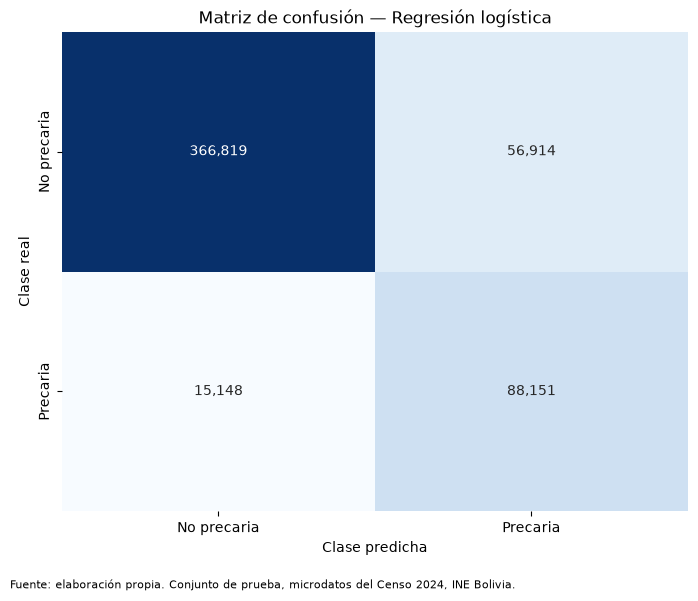

In [7]:
FUENTE_MODELO = "Fuente: elaboración propia. Conjunto de prueba, microdatos del Censo 2024, INE Bolivia."
def metricas(nombre, pred, prob):
    return {"Modelo":nombre,"Accuracy":accuracy_score(y_test,pred),
            "Precision":precision_score(y_test,pred,zero_division=0),
            "Recall":recall_score(y_test,pred,zero_division=0),
            "F1":f1_score(y_test,pred,zero_division=0),
            "ROC-AUC":roc_auc_score(y_test,prob)}

def grafico_confusion(cm,titulo):
    fig,ax = plt.subplots(figsize=(7,6))
    sns.heatmap(cm,annot=True,fmt=",d",cmap="Blues",cbar=False,ax=ax,
                xticklabels=["No precaria","Precaria"],yticklabels=["No precaria","Precaria"])
    ax.set(title=titulo,xlabel="Clase predicha",ylabel="Clase real")
    fig.text(0.01,0.01,FUENTE_MODELO,fontsize=8)
    fig.tight_layout(rect=(0,0.04,1,1))
    plt.show()

metricas_logit = metricas("Regresión logística",pred_logit,prob_logit)
cm_logit = confusion_matrix(y_test,pred_logit,labels=[0,1])
display(pd.DataFrame([metricas_logit]).round(4))
print("Matriz de confusión (filas reales, columnas predichas):\n",cm_logit)
print(classification_report(y_test,pred_logit,target_names=["No precaria","Precaria"],zero_division=0))
grafico_confusion(cm_logit,"Matriz de confusión — Regresión logística")

## 6. Coeficientes de la regresión logística

Recuperamos nombres del encoder ya ajustado. Un coeficiente positivo se asocia con mayores log-odds estimadas de la clase 1 y uno negativo con menores log-odds, manteniendo constantes las demás características del modelo. El odds ratio es `exp(coeficiente)`. Cada categoría One-Hot se compara con la **primera categoría observada en entrenamiento** para su variable. Ni coeficientes ni odds ratios demuestran causalidad.

Categoría omitida por variable (referencia):


,Variable,Categoría de referencia
0,urbrur,1
1,v01_tipoviv,1
2,v03_pared,1
3,v05_techo,1
4,v06_piso,1
5,v11_basura,1
6,v13_habitac,1
7,v14_dormit,0
8,v17_tenencia,1
9,tip_hog,1


Mayores coeficientes positivos:


,Variable/categoría,Coeficiente,Odds ratio
26,categoricas__v11_basura_4,1.5128,4.5392
28,categoricas__v11_basura_6,1.3880,4.0070
3,categoricas__v01_tipoviv_4,1.3879,4.0064
27,categoricas__v11_basura_5,1.2338,3.4344
29,categoricas__v11_basura_7,1.1728,3.2309
25,categoricas__v11_basura_3,1.0905,2.9758
0,categoricas__urbrur_2,0.9969,2.7099
5,categoricas__v01_tipoviv_6,0.9148,2.4962
10,categoricas__v03_pared_6,0.8160,2.2615
8,categoricas__v03_pared_4,0.7139,2.0419


Mayores coeficientes negativos:


,Variable/categoría,Coeficiente,Odds ratio
2,categoricas__v01_tipoviv_3,-6.7103,0.0012
18,categoricas__v06_piso_4,-1.7969,0.1658
17,categoricas__v06_piso_3,-1.7902,0.1669
20,categoricas__v06_piso_6,-1.5901,0.2039
22,categoricas__v06_piso_8,-1.4888,0.2256
36,categoricas__v13_habitac_8,-1.2931,0.2744
35,categoricas__v13_habitac_7,-1.2132,0.2973
19,categoricas__v06_piso_5,-1.0762,0.3409
16,categoricas__v06_piso_2,-1.0361,0.3548
34,categoricas__v13_habitac_6,-1.0214,0.3601


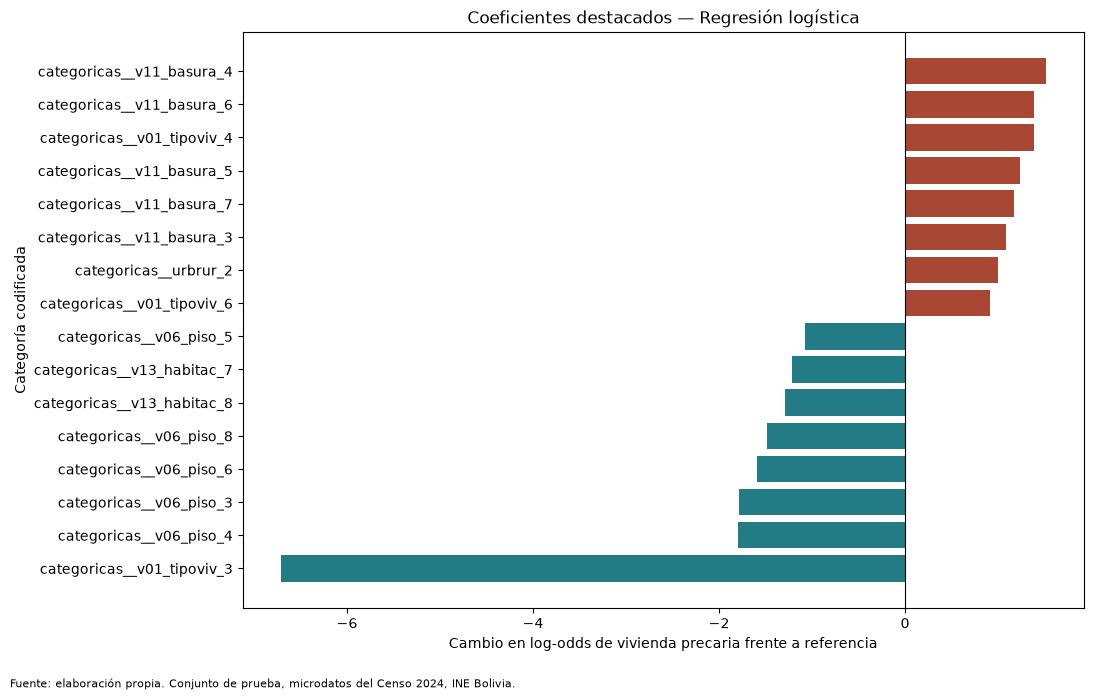

In [8]:
prep_logit = modelo_logistico.named_steps["preprocesamiento"]
encoder_logit = prep_logit.named_transformers_["categoricas"]
nombres_logit = prep_logit.get_feature_names_out()
coef = modelo_logistico.named_steps["clasificador"].coef_[0]
assert len(nombres_logit)==len(coef)
tabla_coef = pd.DataFrame({"Variable/categoría":nombres_logit,"Coeficiente":coef,
                           "Odds ratio":np.exp(coef)})
referencias = pd.DataFrame({"Variable":predictoras,
                            "Categoría de referencia":[categorias[0] for categorias in encoder_logit.categories_]})
print("Categoría omitida por variable (referencia):")
display(referencias)
print("Mayores coeficientes positivos:")
display(tabla_coef.nlargest(10,"Coeficiente").round(4))
print("Mayores coeficientes negativos:")
display(tabla_coef.nsmallest(10,"Coeficiente").round(4))
relevantes = pd.concat([tabla_coef.nlargest(8,"Coeficiente"),tabla_coef.nsmallest(8,"Coeficiente")]).drop_duplicates().sort_values("Coeficiente")
fig,ax = plt.subplots(figsize=(11,7))
ax.barh(relevantes["Variable/categoría"],relevantes["Coeficiente"],
        color=np.where(relevantes["Coeficiente"]>=0,"#a94735","#237b86"))
ax.axvline(0,color="black",linewidth=0.8)
ax.set(title="Coeficientes destacados — Regresión logística",xlabel="Cambio en log-odds de vivienda precaria frente a referencia",ylabel="Categoría codificada")
fig.text(0.01,0.01,FUENTE_MODELO,fontsize=8)
fig.tight_layout(rect=(0,0.04,1,1))
plt.show()

## 7. Árbol de decisión y control de complejidad

Comparamos dos configuraciones acotadas mediante una partición de validación **dentro del entrenamiento**. El árbol base usa profundidad 3 y un mínimo de 5.000 viviendas por hoja; el candidato permite profundidad 5 con el mismo mínimo. Seleccionamos por F1 de validación de la clase precaria y, en empate, preferimos el árbol más simple. Luego reajustamos la configuración elegida con todo el entrenamiento. La prueba se reserva para la evaluación final.

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

X_ajuste,X_val,y_ajuste,y_val = train_test_split(X_train,y_train,test_size=0.20,
                                                random_state=42,stratify=y_train)
configuraciones = [
    {"nombre":"Base","max_depth":3,"min_samples_leaf":5000,"min_samples_split":10000},
    {"nombre":"Candidato","max_depth":5,"min_samples_leaf":5000,"min_samples_split":10000},
]
resultados_validacion = []
for cfg in configuraciones:
    modelo = Pipeline([
        ("preprocesamiento",preparar()),
        ("clasificador",DecisionTreeClassifier(max_depth=cfg["max_depth"],
            min_samples_leaf=cfg["min_samples_leaf"],min_samples_split=cfg["min_samples_split"],
            class_weight="balanced",random_state=42))])
    modelo.fit(X_ajuste,y_ajuste)
    pred_val = modelo.predict(X_val)
    resultados_validacion.append({**cfg,"F1_validación":f1_score(y_val,pred_val),
                                   "Recall_validación":recall_score(y_val,pred_val)})
    del modelo
tabla_validacion = pd.DataFrame(resultados_validacion)
display(tabla_validacion.round(4))
mejor = tabla_validacion.sort_values(["F1_validación","max_depth"],ascending=[False,True]).iloc[0]
print("Configuración seleccionada por validación:",mejor["nombre"])
modelo_arbol = Pipeline([
    ("preprocesamiento",preparar()),
    ("clasificador",DecisionTreeClassifier(max_depth=int(mejor["max_depth"]),
        min_samples_leaf=int(mejor["min_samples_leaf"]),min_samples_split=int(mejor["min_samples_split"]),
        class_weight="balanced",random_state=42))])
modelo_arbol.fit(X_train,y_train)
del X_ajuste,X_val,y_ajuste,y_val
_ = gc.collect()

,nombre,max_depth,min_samples_leaf,min_samples_split,F1_validación,Recall_validación
0,Base,3,5000,10000,0.6855,0.8182
1,Candidato,5,5000,10000,0.6921,0.8172


Configuración seleccionada por validación: Candidato


Las siguientes métricas del árbol proceden de la **misma prueba** que se utilizó para evaluar la regresión logística. Ninguna configuración se eligió mirando la prueba.

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Árbol de decisión,0.8601,0.6057,0.8199,0.6967,0.9052


Matriz de confusión (filas reales, columnas predichas):
 [[368593  55140]
 [ 18606  84693]]
              precision    recall  f1-score   support

 No precaria       0.95      0.87      0.91    423733
    Precaria       0.61      0.82      0.70    103299

    accuracy                           0.86    527032
   macro avg       0.78      0.84      0.80    527032
weighted avg       0.88      0.86      0.87    527032



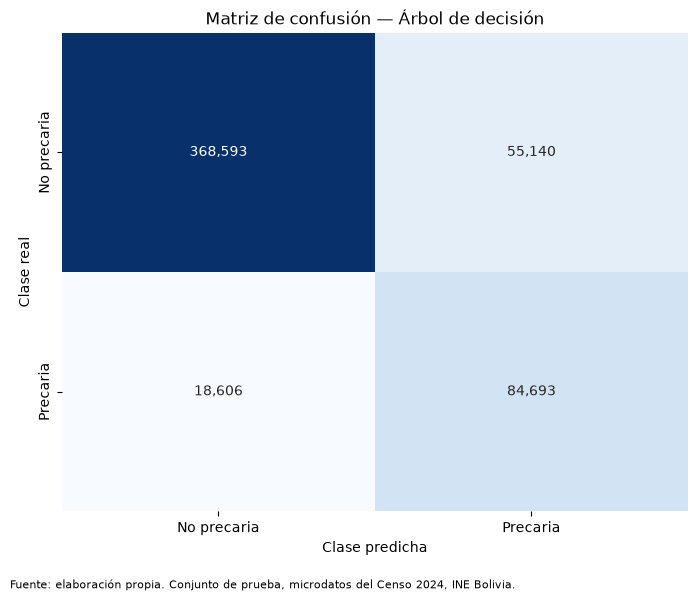

In [10]:
prob_arbol = modelo_arbol.predict_proba(X_test)[:,1]
pred_arbol = (prob_arbol>=0.5).astype("int8")
metricas_arbol = metricas("Árbol de decisión",pred_arbol,prob_arbol)
cm_arbol = confusion_matrix(y_test,pred_arbol,labels=[0,1])
display(pd.DataFrame([metricas_arbol]).round(4))
print("Matriz de confusión (filas reales, columnas predichas):\n",cm_arbol)
print(classification_report(y_test,pred_arbol,target_names=["No precaria","Precaria"],zero_division=0))
grafico_confusion(cm_arbol,"Matriz de confusión — Árbol de decisión")

## 8. Importancia y visualización del árbol

`feature_importances_` resume la reducción de impureza atribuida a cada categoría codificada. Describe el uso interno del árbol; no demuestra causalidad. Recuperamos los nombres del preprocesamiento ajustado.

,Variable/categoría,Importancia
0,categoricas__urbrur_2,0.80900
3,categoricas__v01_tipoviv_4,0.03795
27,categoricas__v11_basura_5,0.03722
18,categoricas__v06_piso_4,0.03698
24,categoricas__v11_basura_2,0.03119
19,categoricas__v06_piso_5,0.02008
37,categoricas__v14_dormit_1,0.01797
5,categoricas__v01_tipoviv_6,0.00332
17,categoricas__v06_piso_3,0.00264
54,categoricas__tip_hog_4,0.00196


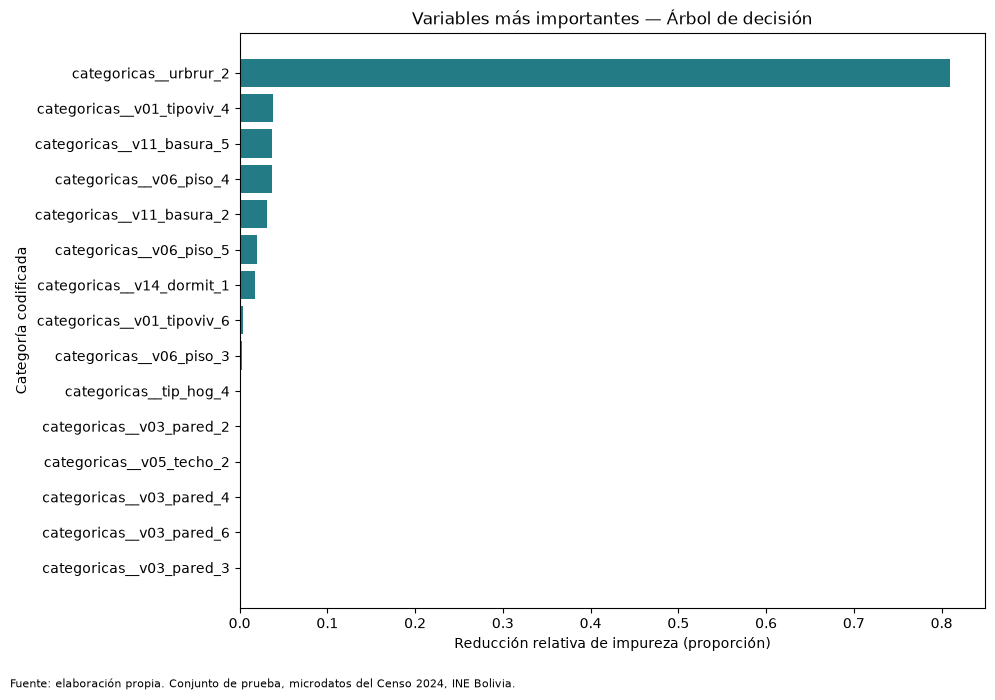

In [11]:
pre_arbol = modelo_arbol.named_steps["preprocesamiento"]
arbol = modelo_arbol.named_steps["clasificador"]
nombres_arbol = pre_arbol.get_feature_names_out()
assert len(nombres_arbol)==len(arbol.feature_importances_)
importancias = pd.DataFrame({"Variable/categoría":nombres_arbol,
                             "Importancia":arbol.feature_importances_}).sort_values("Importancia",ascending=False)
display(importancias.head(15).round(5))
top15 = importancias.head(15).sort_values("Importancia")
fig,ax = plt.subplots(figsize=(10,7))
ax.barh(top15["Variable/categoría"],top15["Importancia"],color="#237b86")
ax.set(title="Variables más importantes — Árbol de decisión",xlabel="Reducción relativa de impureza (proporción)",ylabel="Categoría codificada")
fig.text(0.01,0.01,FUENTE_MODELO,fontsize=8)
fig.tight_layout(rect=(0,0.04,1,1))
plt.show()

La figura muestra únicamente los primeros tres niveles para mantenerla legible. Si el árbol final es más profundo, es una **vista parcial**. La ruta se obtiene de una vivienda real de prueba, con las condiciones del árbol entrenado.

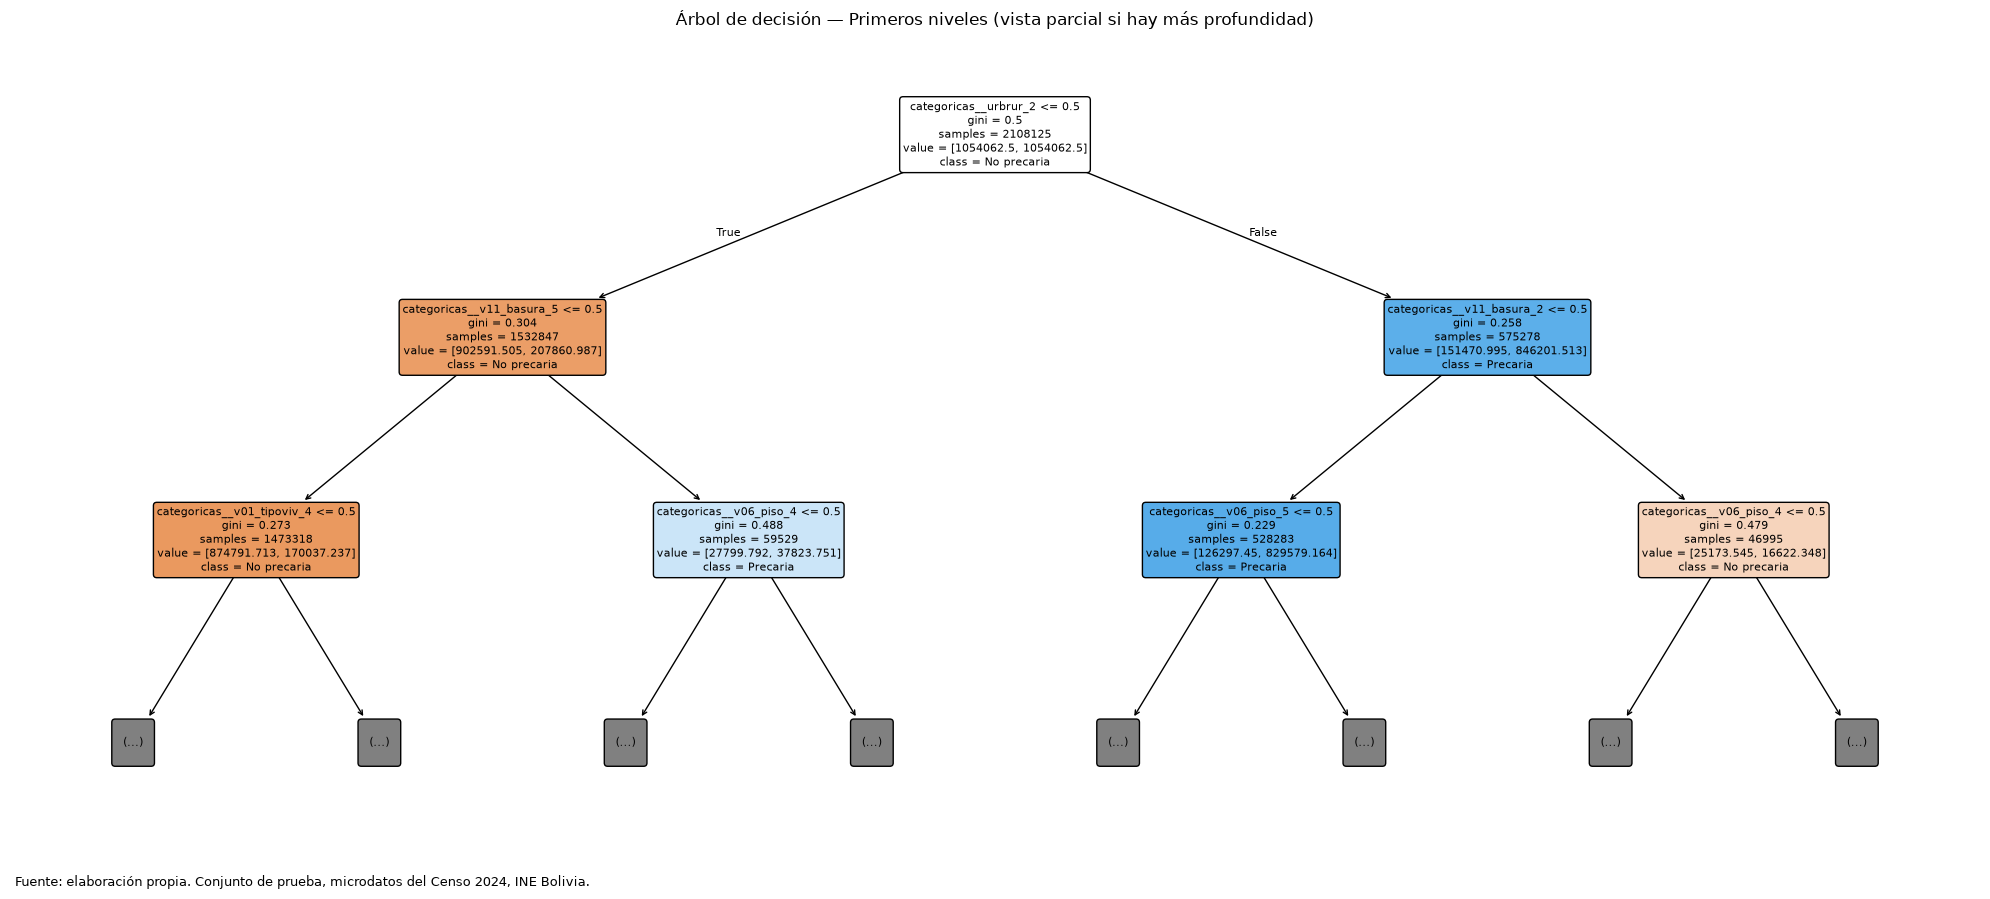

Índice original de vivienda de prueba: 2087807
Condiciones de la ruta real:
   categoricas__urbrur_2 (0) <= 0.50
   categoricas__v11_basura_5 (0) <= 0.50
   categoricas__v01_tipoviv_4 (0) <= 0.50
   categoricas__v14_dormit_1 (0) <= 0.50
   categoricas__v01_tipoviv_6 (0) <= 0.50
Hoja: 5 | Muestras de entrenamiento en hoja: 881452 | Clase predicha: 0 | Probabilidad estimada de clase 1: 0.0691


**Ruta real de una vivienda de prueba:** categoricas__urbrur_2 (0) <= 0.50; después categoricas__v11_basura_5 (0) <= 0.50; después categoricas__v01_tipoviv_4 (0) <= 0.50; después categoricas__v14_dormit_1 (0) <= 0.50; después categoricas__v01_tipoviv_6 (0) <= 0.50. La hoja 5 contiene 881,452 viviendas de entrenamiento y predice la clase **0**. La figura muestra solo los niveles iniciales; la ruta impresa continúa hasta la hoja.

In [12]:
fig,ax = plt.subplots(figsize=(20,9))
plot_tree(arbol,max_depth=2,feature_names=nombres_arbol,
          class_names=["No precaria","Precaria"],filled=True,rounded=True,
          impurity=True,proportion=False,fontsize=8,ax=ax)
ax.set_title("Árbol de decisión — Primeros niveles (vista parcial si hay más profundidad)")
fig.text(0.01,0.01,FUENTE_MODELO,fontsize=9)
fig.tight_layout(rect=(0,0.04,1,1))
plt.show()

fila_ejemplo = X_test.iloc[[0]]
fila_transformada = pre_arbol.transform(fila_ejemplo)
ruta_nodos = arbol.decision_path(fila_transformada).indices
hoja = int(arbol.apply(fila_transformada)[0])
reglas_ruta = []
for nodo in ruta_nodos:
    if nodo == hoja: break
    indice = arbol.tree_.feature[nodo]
    umbral = arbol.tree_.threshold[nodo]
    valor = float(fila_transformada[0,indice])
    operador = "<=" if valor<=umbral else ">"
    reglas_ruta.append(f"{nombres_arbol[indice]} ({valor:.0f}) {operador} {umbral:.2f}")
pred_hoja = int(arbol.predict(fila_transformada)[0])
print("Índice original de vivienda de prueba:",fila_ejemplo.index[0])
print("Condiciones de la ruta real:")
for regla in reglas_ruta: print("  ",regla)
print("Hoja:",hoja,"| Muestras de entrenamiento en hoja:",int(arbol.tree_.n_node_samples[hoja]),
      "| Clase predicha:",pred_hoja,"| Probabilidad estimada de clase 1:",round(float(arbol.predict_proba(fila_transformada)[0,1]),4))
texto_ruta = "; después ".join(reglas_ruta)
display(Markdown(f"**Ruta real de una vivienda de prueba:** {texto_ruta}. La hoja {hoja} contiene {int(arbol.tree_.n_node_samples[hoja]):,} viviendas de entrenamiento y predice la clase **{pred_hoja}**. La figura muestra solo los niveles iniciales; la ruta impresa continúa hasta la hoja."))

## 9. Comparación de modelos y errores relevantes

Todas las métricas proceden del mismo conjunto de prueba, con clase positiva `1 = vivienda precaria` y umbral 0,5. Comparamos cada métrica por separado. Para priorización, recall y falsos negativos importan junto con precisión y recursos disponibles.

In [13]:
comparacion = pd.DataFrame([metricas_logit,metricas_arbol]).set_index("Modelo")
display(comparacion.round(4))
for metrica in ["Accuracy","Precision","Recall","F1","ROC-AUC"]:
    ganador = comparacion[metrica].idxmax()
    print(f"Mayor {metrica}: {ganador} ({comparacion.loc[ganador,metrica]:.4f})")
errores = pd.DataFrame([
    {"Modelo":"Regresión logística","FN":int(cm_logit[1,0]),"FP":int(cm_logit[0,1])},
    {"Modelo":"Árbol de decisión","FN":int(cm_arbol[1,0]),"FP":int(cm_arbol[0,1])}])
display(errores)
recomendado = comparacion["Recall"].idxmax()
display(Markdown(f"Para una **priorización exploratoria** que busque no omitir viviendas realmente precarias, el modelo con mayor recall en prueba es **{recomendado}**. Esta elección debe contrastarse con falsos positivos, precisión y recursos disponibles; no equivale a una decisión automática sobre viviendas individuales."))

,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Regresión logística,0.8633,0.6077,0.8534,0.7099,0.9303
Árbol de decisión,0.8601,0.6057,0.8199,0.6967,0.9052


Mayor Accuracy: Regresión logística (0.8633)
Mayor Precision: Regresión logística (0.6077)
Mayor Recall: Regresión logística (0.8534)
Mayor F1: Regresión logística (0.7099)
Mayor ROC-AUC: Regresión logística (0.9303)


,Modelo,FN,FP
0,Regresión logística,15148,56914
1,Árbol de decisión,18606,55140


Para una **priorización exploratoria** que busque no omitir viviendas realmente precarias, el modelo con mayor recall en prueba es **Regresión logística**. Esta elección debe contrastarse con falsos positivos, precisión y recursos disponibles; no equivale a una decisión automática sobre viviendas individuales.

Un **falso negativo** es una vivienda realmente precaria clasificada como no precaria y podría quedar fuera de revisión. Un **falso positivo** es una vivienda no precaria clasificada como precaria y consumiría recursos de revisión. Si el fin es detectar casos para evaluación posterior, conviene vigilar falsos negativos, pero reducirlos mediante un umbral menor suele aumentar falsos positivos. No se ajustó el umbral con la prueba.

## 10. Respuestas para la evaluación oral — Preguntas 6 a 10

Las respuestas siguientes se generan desde los resultados de esta ejecución. Las figuras de coeficientes, matrices y árbol están en las secciones anteriores.

In [14]:
top_arbol = importancias.iloc[0]
top_logit = tabla_coef.loc[tabla_coef["Coeficiente"].abs().idxmax()]
respuestas = [
    f"**6. Objetivo y modelos.** La clase positiva es vivienda_precaria=1 con dos o más carencias; 0 con cero o una. Se compararon regresión logística y árbol para predecirla desde características habitacionales ajenas a su definición. Población con clase: {len(y):,} viviendas.",
    f"**7. Partición y fuga.** Entrenamiento: {len(X_train):,} ({100*len(X_train)/len(X):.1f}%); prueba: {len(X_test):,} ({100*len(X_test)/len(X):.1f}%). random_state=42 y stratify=y. Variables de servicios y derivadas excluidas; encoder ajustado solo en entrenamiento dentro de pipelines; índices de train y test sin solapamiento.",
    f"**8. Variables importantes.** En el árbol, la categoría con mayor reducción de impureza es {top_arbol['Variable/categoría']} (importancia {top_arbol['Importancia']:.4f}); la mayor magnitud de coeficiente logístico corresponde a {top_logit['Variable/categoría']} ({top_logit['Coeficiente']:+.4f}). Son asociaciones del modelo, no efectos causales.",
    f"**9. Desempeño en prueba.** Logística: accuracy {metricas_logit['Accuracy']:.3f}, precisión {metricas_logit['Precision']:.3f}, recall {metricas_logit['Recall']:.3f}, F1 {metricas_logit['F1']:.3f}, AUC {metricas_logit['ROC-AUC']:.3f}; matriz {cm_logit.tolist()}. Árbol: accuracy {metricas_arbol['Accuracy']:.3f}, precisión {metricas_arbol['Precision']:.3f}, recall {metricas_arbol['Recall']:.3f}, F1 {metricas_arbol['F1']:.3f}, AUC {metricas_arbol['ROC-AUC']:.3f}; matriz {cm_arbol.tolist()}. Los FN son {int(cm_logit[1,0]):,} y {int(cm_arbol[1,0]):,}; los FP, {int(cm_logit[0,1]):,} y {int(cm_arbol[0,1]):,}. Para priorización importa vigilar FN sin disparar FP.",
    f"**10. Interpretación visual.** El árbol muestra reglas, impureza, muestras y clase en sus primeros niveles. Ruta de una vivienda de prueba: {texto_ruta}; hoja {hoja}, clase {pred_hoja}. El gráfico logístico muestra coeficientes positivos y negativos frente a referencias; ayuda a interpretar asociaciones, no causalidad."
]
display(Markdown("\n\n".join(respuestas)))

**6. Objetivo y modelos.** La clase positiva es vivienda_precaria=1 con dos o más carencias; 0 con cero o una. Se compararon regresión logística y árbol para predecirla desde características habitacionales ajenas a su definición. Población con clase: 2,635,157 viviendas.

**7. Partición y fuga.** Entrenamiento: 2,108,125 (80.0%); prueba: 527,032 (20.0%). random_state=42 y stratify=y. Variables de servicios y derivadas excluidas; encoder ajustado solo en entrenamiento dentro de pipelines; índices de train y test sin solapamiento.

**8. Variables importantes.** En el árbol, la categoría con mayor reducción de impureza es categoricas__urbrur_2 (importancia 0.8090); la mayor magnitud de coeficiente logístico corresponde a categoricas__v01_tipoviv_3 (-6.7103). Son asociaciones del modelo, no efectos causales.

**9. Desempeño en prueba.** Logística: accuracy 0.863, precisión 0.608, recall 0.853, F1 0.710, AUC 0.930; matriz [[366819, 56914], [15148, 88151]]. Árbol: accuracy 0.860, precisión 0.606, recall 0.820, F1 0.697, AUC 0.905; matriz [[368593, 55140], [18606, 84693]]. Los FN son 15,148 y 18,606; los FP, 56,914 y 55,140. Para priorización importa vigilar FN sin disparar FP.

**10. Interpretación visual.** El árbol muestra reglas, impureza, muestras y clase en sus primeros niveles. Ruta de una vivienda de prueba: categoricas__urbrur_2 (0) <= 0.50; después categoricas__v11_basura_5 (0) <= 0.50; después categoricas__v01_tipoviv_4 (0) <= 0.50; después categoricas__v14_dormit_1 (0) <= 0.50; después categoricas__v01_tipoviv_6 (0) <= 0.50; hoja 5, clase 0. El gráfico logístico muestra coeficientes positivos y negativos frente a referencias; ayuda a interpretar asociaciones, no causalidad.

## 11. Alcance y límites

La validación aleatoria por vivienda puede compartir patrones territoriales entre entrenamiento y prueba; no mide generalización a otros censos o lugares. La clase se construyó con reglas operacionales solo para viviendas con las cuatro dimensiones clasificables. Las excluidas pueden diferir sistemáticamente. El modelo puede orientar análisis agregados, pero no sustituye revisión territorial, validación de las reglas ni decisiones individuales. La prueba no se usó para ajustar preprocesamiento ni profundidad del árbol.